<a href="https://colab.research.google.com/github/alortiz05/DSBC_Cohort16-Projects/blob/main/SQL_1_Chinook_project_template_ALO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project SQL - Chinook


## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


#NOTES FROM CLASS:
This is a Database with a dataset.....now we need to come up with the question and use SQL to answer the questions. This is not an exercise in answering the below questions. Look at the data and be familiar enough to ask questions of the data and answer them

In [ ]:
# Install the sqlite package for Ubuntu
# Download the Chinook sqlite database


## Come up with questions about your data
Have a look at the Entity-Relation ( ER ) diagram to help come up with questions.

* What sort of information is in this dataset?
* How many records are there?
* How many different countries (states, counties, cities, etc) have records in this data set?


If you are stuck, here are some ideas for questions:
- https://github.com/LucasMcL/15-sql_queries_02-chinook/blob/master/README.md
- [Using the R language]( https://rpubs.com/enext777/636199 )
- [Search Google]( https://www.google.com/search?q=chinook+database+questions )



## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods etc. Make sure and use AT LEAST 13 of the 15 SQL options listed below. (You may have to get creative and come up with more questions to ask/answer.)


### Basic Queries


In [ ]:
import sqlite3 as db
import pandas as pd
import seaborn as sns

In [ ]:
%%capture
%%bash
apt-get update
apt-get install -y sqlite3

In [ ]:
%%bash
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -l chinook.zip


Archive:  chinook.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   884736  2015-11-29 10:53   chinook.db
---------                     -------
   884736                     1 file


In [ ]:
!rm -f chinook.db


In [ ]:
!unzip -u chinook.zip

Archive:  chinook.zip
  inflating: chinook.db              


In [ ]:
!ls -la

total 1180
drwxr-xr-x 1 root root   4096 Apr  4 15:19 .
drwxr-xr-x 1 root root   4096 Apr  4 15:04 ..
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db
-rw-r--r-- 1 root root 305596 Apr  4 15:19 chinook.zip
drwxr-xr-x 4 root root   4096 Apr  2 13:35 .config
drwxr-xr-x 1 root root   4096 Apr  2 13:35 sample_data


In [ ]:
# Connect to a sqlite database and load a result set into a data frame
db_con = db.connect("chinook.db")
#db is the alias for sqlite

In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select *
  from customers
  limit 10
'''

customers = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
customers

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,None,Ullevålsveien 14,Oslo,None,Norway,0171,+47 22 44 22 22,None,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,None,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4
5,6,Helena,Holý,None,Rilská 3174/6,Prague,None,Czech Republic,14300,+420 2 4177 0449,None,hholy@gmail.com,5
6,7,Astrid,Gruber,None,"Rotenturmstraße 4, 1010 Innere Stadt",Vienne,None,Austria,1010,+43 01 5134505,None,astrid.gruber@apple.at,5
7,8,Daan,Peeters,None,Grétrystraat 63,Brussels,None,Belgium,1000,+32 02 219 03 03,None,daan_peeters@apple.be,4
8,9,Kara,Nielsen,None,Sønder Boulevard 51,Copenhagen,None,Denmark,1720,+453 3331 9991,None,kara.nielsen@jubii.dk,4
9,10,Eduardo,Martins,Woodstock Discos,"Rua Dr. Falcão Filho, 155",São Paulo,SP,Brazil,01007-010,+55 (11) 3033-5446,+55 (11) 3033-4564,eduardo@woodstock.com.br,4


In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select *
  from invoices
  limit 10
'''

invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2009-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2009-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2009-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
3,4,14,2009-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
4,5,23,2009-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86
5,6,37,2009-01-19 00:00:00,Berger Straße 10,Frankfurt,None,Germany,60316,0.99
6,7,38,2009-02-01 00:00:00,Barbarossastraße 19,Berlin,None,Germany,10779,1.98
7,8,40,2009-02-01 00:00:00,"8, Rue Hanovre",Paris,None,France,75002,1.98
8,9,42,2009-02-02 00:00:00,"9, Place Louis Barthou",Bordeaux,None,France,33000,3.96
9,10,46,2009-02-03 00:00:00,3 Chatham Street,Dublin,Dublin,Ireland,None,5.94


In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select *
  from invoice_items
  limit 10
'''

invoice_items = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoice_items

,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity
0,1,1,2,0.99,1
1,2,1,4,0.99,1
2,3,2,6,0.99,1
3,4,2,8,0.99,1
4,5,2,10,0.99,1
5,6,2,12,0.99,1
6,7,3,16,0.99,1
7,8,3,20,0.99,1
8,9,3,24,0.99,1
9,10,3,28,0.99,1


In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select *
  from tracks
  limit 10
'''

tracks = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
tracks

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99
5,6,Put The Finger On You,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",205662,6713451,0.99
6,7,Let's Get It Up,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",233926,7636561,0.99
7,8,Inject The Venom,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",210834,6852860,0.99
8,9,Snowballed,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",203102,6599424,0.99
9,10,Evil Walks,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",263497,8611245,0.99


#### SELECT (with * and with column names)


In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select customerid, firstname, lastname
  from customers
  limit 10
'''

customers = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
customers

,CustomerId,FirstName,LastName
0,1,Luís,Gonçalves
1,2,Leonie,Köhler
2,3,François,Tremblay
3,4,Bjørn,Hansen
4,5,František,Wichterlová
5,6,Helena,Holý
6,7,Astrid,Gruber
7,8,Daan,Peeters
8,9,Kara,Nielsen
9,10,Eduardo,Martins


In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select invoiceid, customerid
  from invoices
  limit 100
'''
invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices

,InvoiceId,CustomerId
0,98,1
1,121,1
2,143,1
3,195,1
4,316,1
...,...,...
95,230,14
96,351,14
97,362,14
98,36,15


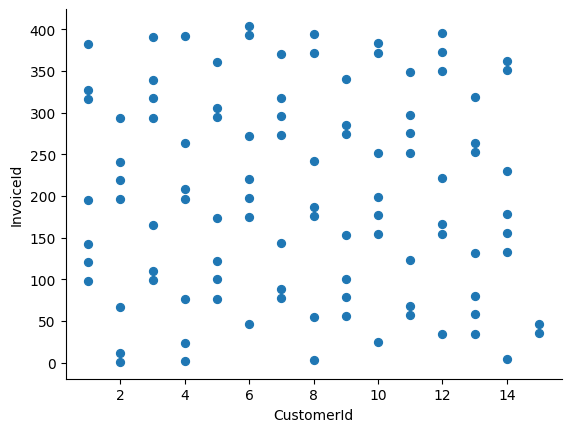

In [ ]:
# @title InvoiceId vs CustomerId

from matplotlib import pyplot as plt
invoices.plot(kind='scatter', x='CustomerId', y='InvoiceId', s=32, alpha=1
              )
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select invoiceid, trackid
  from invoice_items
  limit 10
'''

invoice_items = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoice_items

,InvoiceId,TrackId
0,1,2
1,1,4
2,2,6
3,2,8
4,2,10
5,2,12
6,3,16
7,3,20
8,3,24
9,3,28


In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select trackid, albumid
  from tracks
  limit 10
'''

tracks = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
tracks

,TrackId,AlbumId
0,1,1
1,6,1
2,7,1
3,8,1
4,9,1
5,10,1
6,11,1
7,12,1
8,13,1
9,14,1


In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select albumid, artistid
  from albums
  limit 10
'''

albums = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
albums

,AlbumId,ArtistId
0,1,1
1,4,1
2,2,2
3,3,2
4,5,3
5,6,4
6,7,5
7,8,6
8,34,6
9,9,7


In [ ]:
# Select the first 10 entries from table, retrieves data from the database, * means all columns
#from tells which table to pull from that exists in the database defined above
#python database connector
query = '''
  select *
  from artists
  limit 10
'''

artists = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
artists

,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains
5,6,Antônio Carlos Jobim
6,7,Apocalyptica
7,8,Audioslave
8,9,BackBeat
9,10,Billy Cobham


#### WHERE


I want to try and find the customer country where the album is by Alanis Morissette.

In [42]:
query = '''
SELECT artists.ArtistId, artists.Name, albums.AlbumId, albums.Title, tracks.TrackId, tracks.Name, invoice_items.InvoiceId, invoices.CustomerID, customers.FirstName, customers.LastName, customers.Country
FROM artists
JOIN albums ON artists.ArtistId = albums.ArtistId
JOIN tracks ON albums.AlbumId = tracks.AlbumId
JOIN invoice_items ON tracks.TrackId = invoice_items.TrackId
JOIN invoices ON invoice_items.InvoiceId = invoices.InvoiceId
JOIN customers ON invoices.CustomerId = customers.CustomerId
WHERE artists.Name = 'Alanis Morissette';
'''

artists = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
artists




,ArtistId,Name,AlbumId,Title,TrackId,Name,InvoiceId,CustomerId,FirstName,LastName,Country
0,4,Alanis Morissette,6,Jagged Little Pill,42,Right Through You,4,14,Mark,Philips,Canada
1,4,Alanis Morissette,6,Jagged Little Pill,48,Not The Doctor,4,14,Mark,Philips,Canada
2,4,Alanis Morissette,6,Jagged Little Pill,39,You Oughta Know,320,22,Heather,Leacock,USA
3,4,Alanis Morissette,6,Jagged Little Pill,48,Not The Doctor,320,22,Heather,Leacock,USA
4,4,Alanis Morissette,6,Jagged Little Pill,38,All I Really Want,214,33,Ellie,Sullivan,Canada
5,4,Alanis Morissette,6,Jagged Little Pill,44,You Learn,214,33,Ellie,Sullivan,Canada
6,4,Alanis Morissette,6,Jagged Little Pill,43,Forgiven,109,53,Phil,Hughes,United Kingdom
7,4,Alanis Morissette,6,Jagged Little Pill,49,Wake Up,109,53,Phil,Hughes,United Kingdom


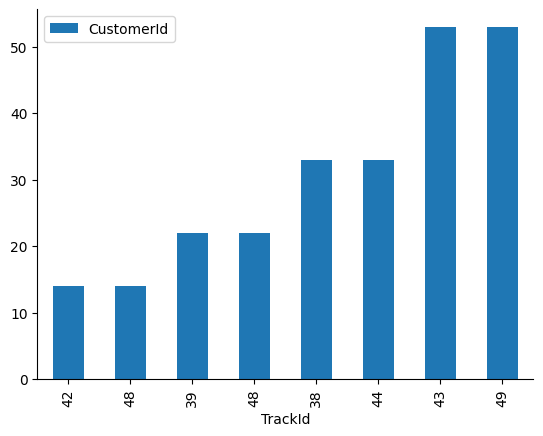

In [ ]:
from matplotlib import pyplot as plt
artists.plot(kind='bar',x='TrackId', y='CustomerId', alpha = 1)
plt.gca().spines[['top', 'right',]].set_visible(False)

#### AND


In [ ]:
query = '''
SELECT artists.ArtistId, artists.Name, albums.ArtistID
FROM artists
JOIN albums ON artists.ArtistId = albums.ArtistId
JOIN tracks ON albums.AlbumId = tracks.AlbumId
WHERE artists.Name = 'Alanis Morissette' AND albums.ArtistId = artists.ArtistId;

'''

artists = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
artists


,ArtistId,Name,ArtistId
0,4,Alanis Morissette,4
1,4,Alanis Morissette,4
2,4,Alanis Morissette,4
3,4,Alanis Morissette,4
4,4,Alanis Morissette,4
5,4,Alanis Morissette,4
6,4,Alanis Morissette,4
7,4,Alanis Morissette,4
8,4,Alanis Morissette,4
9,4,Alanis Morissette,4


#### OR


In [ ]:
query = '''
SELECT artists.ArtistId, artists.Name, albums.ArtistID, albums.AlbumId, tracks.AlbumID, tracks.TrackId, invoice_items.TrackId
FROM artists
JOIN albums ON artists.ArtistId = albums.ArtistId
JOIN tracks ON albums.AlbumId = tracks.AlbumId
JOIN invoice_items ON tracks.TrackId = invoice_items.TrackId
WHERE artists.Name = 'Alanis Morissette' AND (albums.ArtistId = artists.ArtistId OR tracks.TrackId=invoice_items.TrackID) ;

'''

artists = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
artists

,ArtistId,Name,ArtistId,AlbumId,AlbumId,TrackId,TrackId
0,4,Alanis Morissette,4,6,6,38,38
1,4,Alanis Morissette,4,6,6,39,39
2,4,Alanis Morissette,4,6,6,42,42
3,4,Alanis Morissette,4,6,6,43,43
4,4,Alanis Morissette,4,6,6,44,44
5,4,Alanis Morissette,4,6,6,48,48
6,4,Alanis Morissette,4,6,6,48,48
7,4,Alanis Morissette,4,6,6,49,49


#### LIKE (with % or _ wildcard)


In [ ]:
query = '''
SELECT artists.ArtistId, artists.Name, albums.ArtistID, albums.AlbumId, tracks.AlbumID, tracks.TrackId, invoice_items.InvoiceId, invoices.InvoiceId
FROM artists
JOIN albums ON artists.ArtistId = albums.ArtistId
JOIN tracks ON albums.AlbumId = tracks.AlbumId
JOIN invoice_items ON tracks.TrackId = invoice_items.TrackId
JOIN invoices ON invoice_items.InvoiceId = invoices.InvoiceId
WHERE artists.Name = 'Alanis Morissette' AND (albums.ArtistId = artists.ArtistId OR tracks.TrackId=invoice_items.TrackID) AND invoices.InvoiceId LIKE '%1%';

'''



artists = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
artists.head(100)

,ArtistId,Name,ArtistId,AlbumId,AlbumId,TrackId,InvoiceId,InvoiceId
0,4,Alanis Morissette,4,6,6,38,214,214
1,4,Alanis Morissette,4,6,6,43,109,109
2,4,Alanis Morissette,4,6,6,44,214,214
3,4,Alanis Morissette,4,6,6,49,109,109


#### BETWEEN


In [ ]:
query = '''
SELECT artists.ArtistId, artists.Name, albums.ArtistID, albums.AlbumId, tracks.AlbumID, tracks.TrackId, invoice_items.InvoiceId, invoices.InvoiceId, invoices.CustomerID, customers.CustomerID
FROM artists
JOIN albums ON artists.ArtistId = albums.ArtistId
JOIN tracks ON albums.AlbumId = tracks.AlbumId
JOIN invoice_items ON tracks.TrackId = invoice_items.TrackId
JOIN invoices ON invoice_items.InvoiceId = invoices.InvoiceId
JOIN customers ON invoices.CustomerId = customers.CustomerId
WHERE artists.Name = 'Alanis Morissette' AND (albums.ArtistId = artists.ArtistId OR tracks.TrackId=invoice_items.TrackID) AND invoices.InvoiceId LIKE '%1%' AND customers.CustomerID BETWEEN 5 AND 100;

'''



artists = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
artists.head(100)

,ArtistId,Name,ArtistId,AlbumId,AlbumId,TrackId,InvoiceId,InvoiceId,CustomerId,CustomerId
0,4,Alanis Morissette,4,6,6,38,214,214,33,33
1,4,Alanis Morissette,4,6,6,44,214,214,33,33
2,4,Alanis Morissette,4,6,6,43,109,109,53,53
3,4,Alanis Morissette,4,6,6,49,109,109,53,53


#### LIMIT



In [ ]:
query = '''
SELECT artists.ArtistId, artists.Name, albums.ArtistID, albums.AlbumId, tracks.AlbumID, tracks.TrackId, invoice_items.InvoiceId, invoices.InvoiceId, invoices.CustomerID, customers.CustomerID
FROM artists
JOIN albums ON artists.ArtistId = albums.ArtistId
JOIN tracks ON albums.AlbumId = tracks.AlbumId
JOIN invoice_items ON tracks.TrackId = invoice_items.TrackId
JOIN invoices ON invoice_items.InvoiceId = invoices.InvoiceId
JOIN customers ON invoices.CustomerId = customers.CustomerId
LIMIT 10;
'''



artists = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
artists.head(1000)

,ArtistId,Name,ArtistId,AlbumId,AlbumId,TrackId,InvoiceId,InvoiceId,CustomerId,CustomerId
0,158,Battlestar Galactica (Classic),158,253,253,3247,98,98,1,1
1,158,Battlestar Galactica (Classic),158,253,253,3248,98,98,1,1
2,52,Kiss,52,37,37,447,121,121,1,1
3,52,Kiss,52,37,37,449,121,121,1,1
4,52,Kiss,52,37,37,451,121,121,1,1
5,52,Kiss,52,37,37,453,121,121,1,1
6,88,Guns N' Roses,88,90,90,1153,143,143,1,1
7,88,Guns N' Roses,88,90,90,1157,143,143,1,1
8,88,Guns N' Roses,88,91,91,1161,143,143,1,1
9,88,Guns N' Roses,88,91,91,1165,143,143,1,1


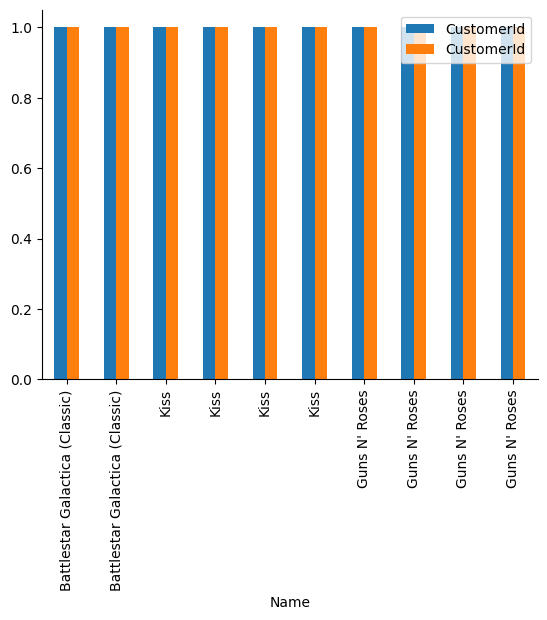

In [ ]:
from matplotlib import pyplot as plt
artists.plot(kind='bar',x='Name', y='CustomerId', alpha = 1)
plt.gca().spines[['top', 'right',]].set_visible(False)

### Sorting and Grouping


#### ORDER BY


In [ ]:
query = '''
  select *
  from invoices
  ORDER BY invoiceid
  limit 10

'''

invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2009-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2009-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2009-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
3,4,14,2009-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
4,5,23,2009-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86
5,6,37,2009-01-19 00:00:00,Berger Straße 10,Frankfurt,None,Germany,60316,0.99
6,7,38,2009-02-01 00:00:00,Barbarossastraße 19,Berlin,None,Germany,10779,1.98
7,8,40,2009-02-01 00:00:00,"8, Rue Hanovre",Paris,None,France,75002,1.98
8,9,42,2009-02-02 00:00:00,"9, Place Louis Barthou",Bordeaux,None,France,33000,3.96
9,10,46,2009-02-03 00:00:00,3 Chatham Street,Dublin,Dublin,Ireland,None,5.94


#### DISTINCT


In [ ]:
query = '''
  SELECT DISTINCT customerid
  FROM invoices
  ORDER BY customerid
  limit 10
'''
invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices

,CustomerId
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


#### GROUP BY



In [ ]:
query = '''
  SELECT invoices.customerid, customers.customerid, customers.Country
  FROM invoices
  JOIN customers ON invoices.customerid = customers.customerid
  ORDER BY customers.Country
 ;
'''
invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices=pd.DataFrame(invoices)
invoices

,CustomerId,CustomerId,Country
0,56,56,Argentina
1,56,56,Argentina
2,56,56,Argentina
3,56,56,Argentina
4,56,56,Argentina
...,...,...,...
407,54,54,United Kingdom
408,54,54,United Kingdom
409,54,54,United Kingdom
410,54,54,United Kingdom


### Aggregates


#### MAX


In [ ]:
query = '''
SELECT MAX(total)
FROM invoices;

'''
invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices

,MAX(total)
0,25.86


#### MIN


In [ ]:
query = '''
SELECT MIN(total)
FROM invoices
JOIN customers ON invoices.customerid = customers.customerid
WHERE customers.country = 'USA';

'''
invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices

,MIN(total)
0,0.99


#### SUM


In [ ]:
query = '''
SELECT SUM(total)
FROM invoices
JOIN customers ON invoices.customerid = customers.customerid
WHERE customers.country = 'USA';

'''
invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices

,SUM(total)
0,523.06


#### AVG


In [ ]:
query = '''
SELECT AVG(total)
FROM invoices
JOIN customers ON invoices.customerid = customers.customerid
WHERE customers.country = 'USA';

'''
invoices = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
invoices

,AVG(total)
0,5.747912


#### COUNT



In [ ]:
query = '''
  select COUNT(DISTINCT name)
  from artists
  limit 10
'''

artists = pd.read_sql_query( query , db_con)#connect to the database and query the results and put in a pandas dataframe
artists

,COUNT(DISTINCT name)
0,275


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something
* Come up with something else cool to do with your data


In [ ]:
query = '''
WITH CustomerArtistPurchases AS (
    SELECT
        c.CustomerId,  -- CustomerId from Customers table
        a.ArtistId,    -- ArtistId from Tracks table
        COUNT(DISTINCT t.TrackId) AS TracksPurchased
    FROM
        Customers c
    JOIN
        Invoices i ON c.CustomerId = i.CustomerId  -- Use c.CustomerId here
    JOIN
        Invoice_Items ii ON i.InvoiceId = ii.InvoiceId
    JOIN
        Tracks t ON ii.TrackId = t.TrackId
    JOIN
        Albums a ON t.AlbumId = a.AlbumId
    GROUP BY
        c.CustomerId, a.ArtistId  -- Group by c.CustomerId (from Customers) and t.ArtistId (from Tracks)
)
SELECT
    CustomerId,
    ArtistId,
    TracksPurchased
FROM
    CustomerArtistPurchases
ORDER BY
    CustomerId, TracksPurchased DESC;
'''


In [ ]:
# Execute the query and load the result into a DataFrame
df = pd.read_sql_query(query, db_con)

# The DataFrame will automatically be printed in Jupyter Notebook
df

,CustomerId,ArtistId,TracksPurchased
0,1,88,6
1,1,113,6
2,1,21,4
3,1,52,4
4,1,18,3
...,...,...,...
918,59,37,1
919,59,57,1
920,59,58,1
921,59,122,1


this was super hard but I can see how this could save a lot of time to do what I was trying to do above.